In [8]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
import statsmodels.formula.api as smf

In [ ]:
def run_simulation(n_iters, n_samples, n_features, k_select, alpha=0.05, seed=123):
    if n_iters < 2 or n_samples <= 4 or n_features < 1:
        raise ValueError("Use n_iters >= 2, n_samples > 4, and n_features >= 1.")
    if not 1 <= k_select <= n_features or not 0 < alpha < 1:
        raise ValueError("Require 1 <= k_select <= n_features and 0 < alpha < 1.")
    data_seed, random_seed = np.random.SeedSequence(seed).spawn(2)
    data_rng = np.random.default_rng(data_seed)
    random_rng = np.random.default_rng(random_seed)
    pvals_shap = []
    pvals_random = []
    
    for _ in range(n_iters):
        # [1] グローバル帰無仮説下のデータ生成
        X = data_rng.standard_normal((n_samples, n_features))
        y = data_rng.standard_normal(n_samples)
        
        df = pd.DataFrame(X, columns=[f"x{i}" for i in range(n_features)])
        df["y"] = y
        
        # [2] Random Forest と SHAP 重要度
        model = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
        model.fit(X, y)
        
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X)
        mean_abs_shap = np.abs(shap_values).mean(axis=0)
        
        # [3] SHAP 選択とランダム選択
        # SHAP 選択
        shap_selected_idx = np.lexsort((np.arange(n_features), -mean_abs_shap))[:k_select]
        # ランダム選択
        random_selected_idx = random_rng.choice(n_features, size=k_select, replace=False)
        
        # [4] ランダム選択後の B スプライン F 検定
        for idx in random_selected_idx:
            formula = f"y ~ bs(x{idx}, df=3)"
            result = smf.ols(formula, data=df).fit()
            pvals_random.append(result.f_pvalue)
        
        # [5] SHAP 選択後の Naive 検定
        for idx in shap_selected_idx:
            formula = f"y ~ bs(x{idx}, df=3)"
            result = smf.ols(formula, data=df).fit()
            pvals_shap.append(result.f_pvalue)

    # [6] 経験的 FPR
    pvals_shap = np.array(pvals_shap)
    pvals_random = np.array(pvals_random)
    
    shap_rates = (pvals_shap < alpha).reshape(n_iters, k_select).mean(axis=1)
    random_rates = (pvals_random < alpha).reshape(n_iters, k_select).mean(axis=1)
    fpr_shap, fpr_random = shap_rates.mean(), random_rates.mean()
    se_shap = shap_rates.std(ddof=1) / np.sqrt(n_iters)
    se_random = random_rates.std(ddof=1) / np.sqrt(n_iters)
    
    print("\n=== Simulation Results ===")
    print(f"Random baseline selected-hypothesis FPR : {fpr_random:.3f} (SE {se_random:.3f})")
    print(f"Naive post-SHAP selected-hypothesis FPR : {fpr_shap:.3f} (SE {se_shap:.3f})")
    
    # [6] p 値分布
    plt.figure(figsize=(10, 5))
    
    plt.hist(pvals_random, bins=20, range=(0, 1), alpha=0.5, 
             label=f'Random baseline (FPR: {fpr_random:.3f})', color='gray', edgecolor='black')
    
    plt.hist(pvals_shap, bins=20, range=(0, 1), alpha=0.5, 
             label=f'Naive post-SHAP (FPR: {fpr_shap:.3f})', color='blue', edgecolor='black')
    
    plt.axvline(alpha, color='red', linestyle='--', linewidth=2, label=f'Alpha Threshold ({alpha})')
    
    plt.title('Naive post-SHAP inference vs random calibration baseline (global null)')
    plt.xlabel('P-value')
    plt.ylabel('Frequency')
    plt.xlim(0, 1)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()
    return {"pvals_shap": pvals_shap, "pvals_random": pvals_random,
            "fpr_shap": fpr_shap, "fpr_random": fpr_random,
            "se_shap": se_shap, "se_random": se_random}


=== Simulation Results ===
Random baseline selected-hypothesis FPR : 0.060 (SE 0.008)
Naive post-SHAP selected-hypothesis FPR : 0.361 (SE 0.015)


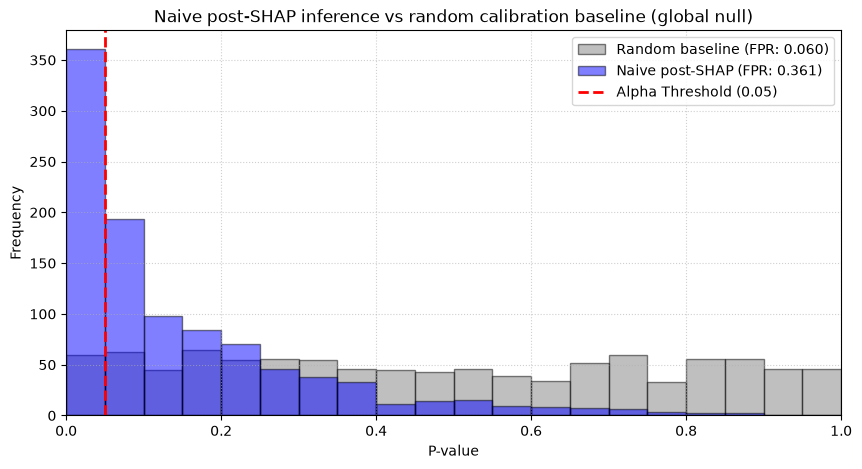

In [10]:
# [1] グローバル帰無仮説
results = run_simulation(n_iters=1000, n_samples=100, n_features=20, k_select=1, seed=123)